In [1]:
import numpy as np

import pennylane as qml
import matplotlib.pyplot as plt

In [2]:
device = qml.device("qiskit.aer", wires=5)

In [3]:
from pennylane.measurements import ExpectationMP

# set qubit state from angle matrix
def init_qubit(matrix: np.ndarray, qubit: int):
    qml.RX(phi=matrix[0], wires=qubit)
    qml.RY(phi=matrix[1], wires=qubit)
    qml.RZ(phi=matrix[2], wires=qubit)

# get qubit state as matrix
def get_qubit_state(qubit: int) -> tuple[ExpectationMP, ExpectationMP, ExpectationMP]:
    return qml.expval(qml.PauliX(wires=qubit)), qml.expval(qml.PauliY(wires=qubit)), qml.expval(qml.PauliZ(wires=qubit))

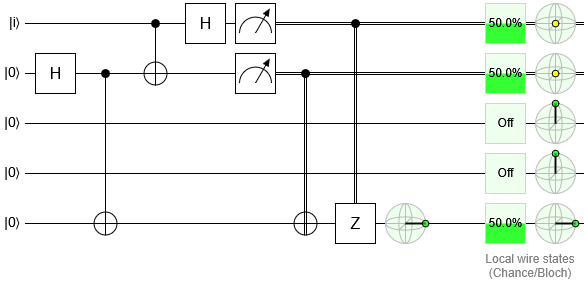

In [4]:
INITIAL_QBIT = 0
ALICE_QBIT = 1
BOB_QBIT = 4

In [5]:
@qml.qnode(device)
def quantum_teleport(matrix: np.ndarray):
    init_qubit(matrix, INITIAL_QBIT)

    qml.Hadamard(wires=ALICE_QBIT)
    qml.CNOT(wires=[ALICE_QBIT, BOB_QBIT])
    qml.CNOT(wires=[INITIAL_QBIT, ALICE_QBIT])
    qml.Hadamard(wires=INITIAL_QBIT)

    # measure 1 and 2 qubits
    m0 = qml.measure(INITIAL_QBIT)
    m1 = qml.measure(ALICE_QBIT)
    
    qml.cond(m1, qml.PauliX)(wires=BOB_QBIT) # type: ignore
    qml.cond(m0, qml.PauliZ)(wires=BOB_QBIT) # type: ignore

    return get_qubit_state(BOB_QBIT)


In [6]:
def Hadamard(wires):
    qml.RZ(np.pi, wires=wires)
    qml.RY(np.pi/2, wires=wires)
    qml.RZ(np.pi, wires=wires)

def MS(wires: list):
    qml.IsingXX(np.pi/2, wires=[wires[0], wires[1]])

# Google SD-style
def CNOT(wires: list):
    _, target = wires
    Hadamard(target)
    qml.CZ(wires=wires)
    qml.Hadamard(target)

def CNOT_ionq(wires: list):
    control, target = wires
    qml.RY(np.pi/2, wires=control)
    MS(wires)
    qml.RX(-np.pi/2, wires=control)
    qml.RX(-np.pi/2, wires=target)
    qml.RY(-np.pi/2, wires=control)

def SWAP(wires: list):
    CNOT(wires)
    CNOT(wires[::-1])
    CNOT(wires)


In [7]:
# ионный
@qml.qnode(device)
def ionq_qt(matrix: np.ndarray):
    init_qubit(matrix, INITIAL_QBIT)
    
    qml.Hadamard(ALICE_QBIT)
    CNOT_ionq([ALICE_QBIT, BOB_QBIT])
    
    CNOT_ionq([INITIAL_QBIT, ALICE_QBIT])
    qml.Hadamard(INITIAL_QBIT)
    
    m0 = qml.measure(INITIAL_QBIT)
    m1 = qml.measure(ALICE_QBIT)
    
    qml.cond(m1, qml.PauliX)(wires=BOB_QBIT)
    qml.cond(m0, qml.PauliZ)(wires=BOB_QBIT)
    
    return get_qubit_state(BOB_QBIT)

In [8]:
# не можем использовать BOB_QBIT, так как он физически отделен

# сверхпроводниковый
@qml.qnode(device)
def sd_qt(matrix: np.ndarray):
    init_qubit(matrix, INITIAL_QBIT)

    new_bob_qbit = BOB_QBIT

    # SWAP BOB_QBIT to ALICE_QBIT+1 position
    if new_bob_qbit - ALICE_QBIT != 1:
        while(new_bob_qbit != ALICE_QBIT + 1):
            SWAP([new_bob_qbit, new_bob_qbit-1])
            new_bob_qbit = new_bob_qbit - 1
            


    qml.Hadamard(ALICE_QBIT)
    CNOT([ALICE_QBIT, new_bob_qbit])
    
    CNOT([INITIAL_QBIT, ALICE_QBIT])
    qml.Hadamard(INITIAL_QBIT)

    m0 = qml.measure(INITIAL_QBIT)
    m1 = qml.measure(ALICE_QBIT)
    
    qml.cond(m1, qml.PauliX)(wires=new_bob_qbit)
    qml.cond(m0, qml.PauliZ)(wires=new_bob_qbit)
    
    return get_qubit_state(new_bob_qbit)


In [9]:
# задаем матрицу углов поворота (X, Y, Z)
matrix = np.array([
    np.pi, np.pi/4, 0
])


print(ionq_qt(matrix))
print(quantum_teleport(matrix))
print(sd_qt(matrix))


print("Количество гейтов в абстрактной схеме", len(quantum_teleport._tape.operations))
print("Количество гейтов в ionq:", len(ionq_qt._tape.operations))
print("Количество гейтов в SD:", len(sd_qt._tape.operations))


e:\Coding\Projects\qml\.venv\Lib\site-packages\pennylane_qiskit\qiskit_device_legacy.py:144: UserWarning: The analytic calculation of expectations, variances and probabilities is only supported on statevector backends, not on the aer_simulator. Such statistics obtained from this device are estimates based on samples.
  warnings.warn(self.analytic_warning_message.format(self.backend_name), UserWarning)


(array(-0.71289062), array(-0.0078125), array(-0.7109375))
(array(-0.67578125), array(0.01171875), array(-0.73046875))
(array(-0.71484375), array(0.02929688), array(-0.71679688))
Количество гейтов в абстрактной схеме 11
Количество гейтов в ionq: 19
Количество гейтов в SD: 49


In [10]:
# ionq_results = [ionq_qt(matrix) for _ in range(1000)]

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed

def run_ionq(matrix):
    myd = qml.device("qiskit.aer", wires=5)

    @qml.qnode(myd)
    def circuit(matrix: np.ndarray):
        init_qubit(matrix, INITIAL_QBIT)
        
        qml.Hadamard(ALICE_QBIT)
        CNOT_ionq([ALICE_QBIT, BOB_QBIT])
        
        CNOT_ionq([INITIAL_QBIT, ALICE_QBIT])
        qml.Hadamard(INITIAL_QBIT)
    
        m0 = qml.measure(INITIAL_QBIT)
        m1 = qml.measure(ALICE_QBIT)
        
        qml.cond(m1, qml.PauliX)(wires=BOB_QBIT)
        qml.cond(m0, qml.PauliZ)(wires=BOB_QBIT)
        
        return get_qubit_state(BOB_QBIT)

    return circuit(matrix)

if __name__ == "__main__":
    with ProcessPoolExecutor(max_workers=4) as executor:
        futures = [executor.submit(run_ionq, matrix) for _ in range(10)]
        results = [f.result() for f in as_completed(futures)]

__main__


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

In [ ]:
results[0]

<Future at 0x29aff6bcdd0 state=finished raised TypeError>

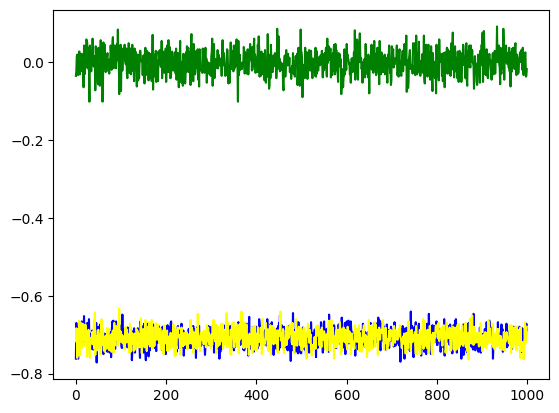

In [ ]:
plt.plot([i[0] for i in ionq_results], color="blue")
plt.plot([i[1] for i in ionq_results], color="green")
plt.plot([i[2] for i in ionq_results], color="yellow")

<BarContainer object of 3 artists>

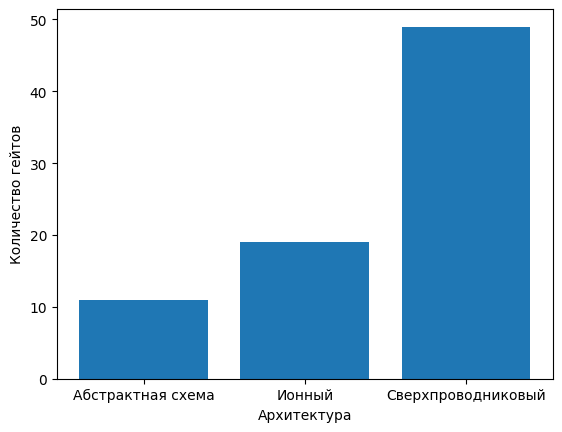

In [15]:

plt.xlabel("Архитектура")
plt.ylabel("Количество гейтов")
plt.bar(["Абстрактная схема", "Ионный", "Сверхпроводниковый"], [len(quantum_teleport._tape.operations), len(ionq_qt._tape.operations), len(sd_qt._tape.operations)])